In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
lead_researcher_prompt = """You are a research supervisor. Your job is to conduct research by calling the "ConductResearch" tool. For context, today's date is {date}.

<Task>
Your focus is to call the "ConductResearch" tool to conduct research against the overall research question passed in by the user. 
When you are completely satisfied with the research findings returned from the tool calls, then you should call the "ResearchComplete" tool to indicate that you are done with your research.
</Task>

<Available Tools>
You have access to three main tools:
1. **ConductResearch**: Delegate research tasks to specialized sub-agents
2. **ResearchComplete**: Indicate that research is complete
3. **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool before calling ConductResearch to plan your approach, and after each ConductResearch to assess progress**
**PARALLEL RESEARCH**: When you identify multiple independent sub-topics that can be explored simultaneously, make multiple ConductResearch tool calls in a single response to enable parallel research execution. This is more efficient than sequential research for comparative or multi-faceted questions. Use at most {max_concurrent_research_units} parallel agents per iteration.
</Available Tools>

<Instructions>
Think like a research manager with limited time and resources. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the research. Are there multiple independent directions that can be explored simultaneously?
3. **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still missing?
</Instructions>

<Hard Limits>
**Task Delegation Budgets** (Prevent excessive delegation):
- **Bias towards single agent** - Use single agent for simplicity unless the user request has clear opportunity for parallelization
- **Stop when you can answer confidently** - Don't keep delegating research for perfection
- **Limit tool calls** - Always stop after {max_researcher_iterations} tool calls to think_tool and ConductResearch if you cannot find the right sources
</Hard Limits>

<Show Your Thinking>
Before you call ConductResearch tool call, use think_tool to plan your approach:
- Can the task be broken down into smaller sub-tasks?

After each ConductResearch tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I delegate more research or call ResearchComplete?
</Show Your Thinking>

<Scaling Rules>
**Simple fact-finding, lists, and rankings** can use a single sub-agent:
- *Example*: List the top 10 coffee shops in San Francisco → Use 1 sub-agent

**Comparisons presented in the user request** can use a sub-agent for each element of the comparison:
- *Example*: Compare OpenAI vs. Anthropic vs. DeepMind approaches to AI safety → Use 3 sub-agents
- Delegate clear, distinct, non-overlapping subtopics

**Important Reminders:**
- Each ConductResearch call spawns a dedicated research agent for that specific topic
- A separate agent will write the final report - you just need to gather information
- When calling ConductResearch, provide complete standalone instructions - sub-agents can't see other agents' work
- Do NOT use acronyms or abbreviations in your research questions, be very clear and specific
</Scaling Rules>"""


In [9]:
import operator
from typing_extensions import Annotated, TypedDict, Sequence

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

class SupervisorState(TypedDict):
    """
    State for the multi-agent research supervisor.
    
    Manages coordination between supervisor and research agents, tracking
    research progress and accumulating findings from multiple sub-agents.
    """
    
    # Messages exchanged with supervisor for coordination and decision-making
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # Detailed research brief that guides the overall research direction
    research_brief: str
    # Processed and structured notes ready for final report generation
    notes: Annotated[list[str], operator.add] = []
    # Counter tracking the number of research iterations performed
    research_iterations: int = 0
    # Raw unprocessed research notes collected from sub-agent research
    raw_notes: Annotated[list[str], operator.add] = []

@tool
class ConductResearch(BaseModel):
    research_topic: str = Field(description = "The topic to research. Should be a single topic, and should be described in high detail (at least a paragraph).")

@tool
class ResearchComplete(BaseModel):
    """Tool for indicating that the research process is complete."""
    pass


# Multi-agent

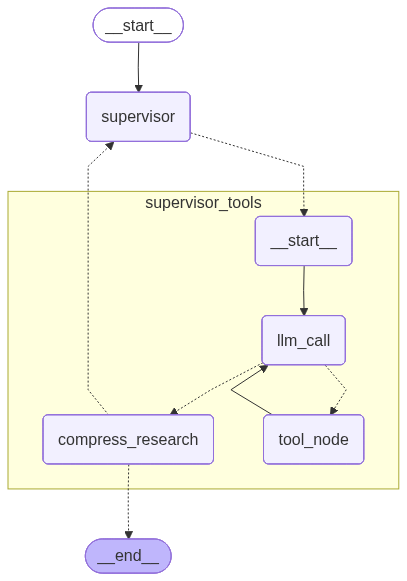

In [10]:
import asyncio

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage, 
    BaseMessage, 
    SystemMessage, 
    ToolMessage,
    filter_messages
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

@tool (parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """Extract research notes from ToolMessage objects in supervisor message history.
    
    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.
    
    Args:
        messages: List of messages from supervisor's conversation history
        
    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    return [tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")]

try:
    import nest_asyncio

    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass
except ImportError:
    pass

supervisor_tools = [ConductResearch, ResearchComplete, think_tool]
supervisor_model = init_chat_model(model='gpt-4o-mini')
supervisor_model_with_tools = supervisor_model.bind_tools(supervisor_tools)

max_researcher_iterations = 6
max_concurrent_researcers = 3

async def supervisor(state: SupervisorState) -> Command[Literal['supervisor_tools']]:
    supervisor_messages = state.get('supervisor_messages',[])
    supervisor_messages = state.get("supervisor_messages", [])
    
    # Prepare system message with current date and constraints
    system_message = lead_researcher_prompt.format(
        date=get_today_str(), 
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages
    
    # Make decision about next research steps
    response = await supervisor_model_with_tools.ainvoke(messages)

    return Command(goto = 'supervisor_tools', update = { 'supervisor_messages': [response],
                                                         'research_iterations': state.get('research_iterations',0) + 1})


async def supervisor_tools(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """Execute supervisor decisions - either conduct research or end the process.
    
    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete
    
    Args:
        state: Current supervisor state with messages and iteration count
        
    Returns:
        Command to continue supervision, end process, or handle errors
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]
    
    # Initialize variables for single return pattern
    tool_messages = []
    all_raw_notes = []
    next_step = "supervisor"  # Default next step
    should_end = False


    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete" 
        for tool_call in most_recent_message.tool_calls)
    
    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END

    else:
        try:
            think_tool_calls = [ tool_call for tool_call in most_recent_message.tool_calls if tool_call['name'] == 'think_tool']
            conduct_research_calls = [tool_call for tool_call in most_recent_message.tool_calls if tool_call['name'] == 'ConductResearch']

            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call['args'])
                tool_messages.append(ToolMessage(content = observation,
                                                 name = tool_call['name'],
                                                 tool_call_id = tool_call['id']))
                
            if conduct_research_calls:
                coros = [researcher_agent.ainvoke({ 'researcher_messages':  [HumanMessage(content=tool_call["args"]["research_topic"])],
                                                    "research_topic": tool_call["args"]["research_topic"] }) 
                                    for tool_call in conduct_research_calls ]
                tool_results = await asyncio.gather(*coros)

                research_tool_messages = [ToolMessage(content = result.get("compressed_research", "Error synthesizing research report"), 
                                                      name = tool_call['name'],
                                                      tool_call_id = tool_call['id']) for result, tool_call in zip(tool_results, conduct_research_calls)]
                tool_messages.extend(research_tool_messages)


                all_raw_notes = [ '/n'.join(result.get('raw_notes',[])) for result in tool_results]
        
        except Exception as e:
            print(f'Error in supervisor tools: {e}')
            should_end = True
            next_step = END

    if should_end:
        return Command( goto = next_step,
                       update = { "notes": get_notes_from_tool_calls(supervisor_messages),
                                  "research_brief": state.get("research_brief", "")}) 
    else: 
        return Command( goto = next_step,
                       update = {"supervisor_messages": tool_messages,
                "raw_notes": all_raw_notes })

supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()

from IPython.display import Image, display
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# Show the agent
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))
            

In [11]:
from utils import format_messages
from langchain_core.messages import HumanMessage

research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = await supervisor_agent.ainvoke({"supervisor_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['supervisor_messages'])

ValueError: Invalid format string

In [12]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

should_parallelize = [
    HumanMessage(content="Compare OpenAI vs Gemini deep research."),
    AIMessage(content="I need to analyze this request to determine if can should be parallelized.", tool_calls=[
        {
            "name": "think_tool",
            "args": {"reflection": "This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research."},
            "id": "call_think_1"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research.", tool_call_id="call_think_1", name="think_tool")
]

should_not_parallelize = [
    HumanMessage(content="What are the top three Chinese restaurants in Chelsea, Manhattan"),
    AIMessage(content="Let me think about whether this task requires parallelization.", tool_calls=[
        {
            "name": "think_tool", 
            "args": {"reflection": "This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan)."},
            "id": "call_think_2"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan).", tool_call_id="call_think_2", name="think_tool")
]

In [13]:
import os
from langsmith import Client

langsmith_client = Client(api_key= os.getenv('LANGSMITH_API_KEY'))

dataset_name = 'deep_research_supervisor_parallelism'

if not langsmith_client.has_dataset(dataset_name = dataset_name):
    dataset = langsmith_client.create_dataset( dataset_name= dataset_name, description = "A dataset that evaluates whether a supervisor can accurately decide when to parallelize research.",
    )
    langsmith_client.create_examples(dataset_id = dataset.id,
                                     examples = [
                                         {
                                             'inputs': {'supervisor_messages': should_parallelize},
                                             'outputs': {'num_expected_threads': 2}
                                         },
                                         {
                                             'inputs' : {'supervisor_messages': should_not_parallelize},
                                             'outputs': {'num_expected_threads': 1}
                                         }
                                     ])

In [ ]:
import uuid

def evaluate_parallelism(outputs: dict, reference_outputs: dict):
    tool_calls = outputs['output'].update['supervisor_messages'][-1].tool_calls
    return {
        'key': 'correct_next_step',
        'score': len(tool_calls) == reference_outputs['num_expected_threads']
        
    }

async def target_func(input: dict):
    config = {'configurable': {'thread_id':uuid.uuid4()}}
    return await supervisor_agent.nodes['supervisor'].ainvoke(inputs)

await langsmith_client.aevaluate(target_func,
                                 data = dataset_name,
                                 evaluators= [evaluate_parallelism],
                                 experiment_prefix = 'Supervisor Parallelism')
